<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

In [54]:
from collections import defaultdict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk

from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
import math

In [55]:
!wget -O SpamEmailClassificationDataset.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true


--2026-07-10 19:27:16--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2026-07-10 19:27:16--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2026-07-10 19:27:16--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip
Res

In [56]:
!unzip SpamEmailClassificationDataset.zip


Archive:  SpamEmailClassificationDataset.zip
replace SpamEmailClassificationDataset/combined_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: SpamEmailClassificationDataset/combined_data.csv  


In [57]:
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [58]:
df = pd.read_csv('SpamEmailClassificationDataset/combined_data.csv')

# random 5000 records
df = df.sample(n=5000, random_state=42)
df = df.reset_index(drop=True)

df.head()


,label,text
0,1,while we may have high expectations of our ass...
1,0,"sorry ,\ndon ' t we need to know the cost , as..."
2,0,paul received the standard business reorg pack...
3,0,mathew 写道 what does gr do it's qr not gr see p...
4,0,croero hotmail com wrote hello i need to impo...


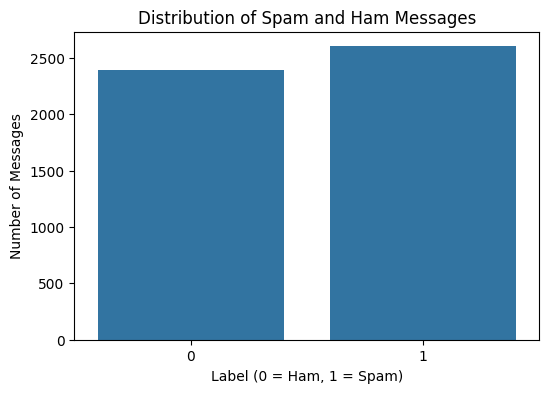

In [59]:
df = df[df['label'] != 'label']

df['label'] = df['label'].astype(int)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Messages")

plt.show()



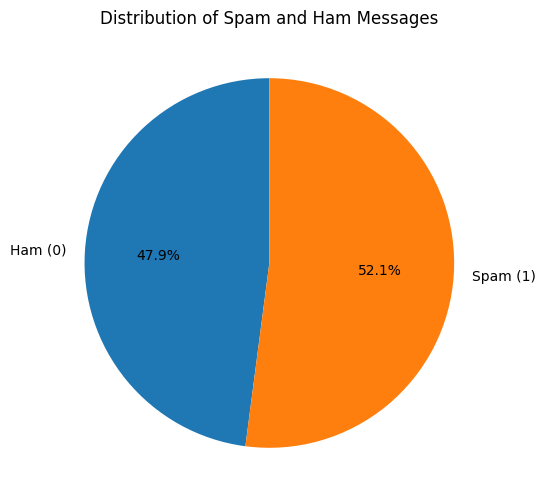

In [60]:
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=['Ham (0)', 'Spam (1)'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Spam and Ham Messages")
plt.show()

In [61]:
corpus = []
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

for document in df["text"]:
    document = re.sub("[^a-zA-Z]", " ", document).lower()
    document = document.split()
    document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
    # print(document)
    document = list(set(document))
    document = " ".join(document)
    corpus.append(document)

df["text"] = corpus

In [62]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_spam = train_df[train_df["label"] == 1]["text"].tolist()

train_ham = train_df[train_df["label"] == 0]["text"].tolist()

test_emails = test_df

In [74]:
vocab_words_spam = []

for sentence in train_spam:
    sentence_as_list = sentence.split()
    for word in sentence_as_list:
        vocab_words_spam.append(word)

print(vocab_words_spam)

vocab_unique_words_spam = list(set(vocab_words_spam))
print(vocab_unique_words_spam)

['please', 'enter', 'losing', 'important', 'offer', 'filter', 'protects', 'blvd', 'la', 'arouse', 'rainbow', 'guaranteed', 'doctoral', 'either', 'vega', 'crestfallen', 'vinson', 'want', 'address', 'possible', 'prev', 'unwanted', 'reply', 'thereon', 'better', 'u', 'believe', 'get', 'wish', 'act', 'email', 'marketing', 'forward', 'judge', 'try', 'requirement', 'spam', 'people', 'hey', 'ia', 'stop', 'n', 'conforms', 'see', 'special', 'owe', 'program', 'actually', 'contacted', 'hollister', 'system', 'without', 'tried', 'rid', 'friend', 'hate', 'legal', 'many', 'solution', 'nv', 'inc', 'ultimate', 'delivers', 'streamlinesenile', 'precautionary', 'judgenaomi', 'cadillac', 'novelstringy', 'buckskinemilio', 'chaperone', 'armpit', 'clutchtruth', 'planquarterback', 'conscriptionderbyshire', 'unsubscribe', 'diphtheria', 'beheld', 'postprocessorpublic', 'capsize', 'battalion', 'query', 'back', 'another', 'men', 'gertrude', 'ago', 'autocad', 'w', 'south', 'rabbit', 'woman', 'environment', 'instead'

In [75]:
tokenized_train_spam = [sentence.split() for sentence in train_spam]

dict_spamicity = {}
total_spam = len(tokenized_train_spam)

for word in vocab_unique_words_spam:
    emails_with_word = sum(word in sentence for sentence in tokenized_train_spam)

    spamicity = (emails_with_word + 1) / (total_spam + 2)

    dict_spamicity[word] = spamicity

print(f"Dictionary size: {len(dict_spamicity)}")

Dictionary size: 33800


In [76]:
top_words = sorted(
    dict_spamicity.items(),
    key=lambda x: x[1],
    reverse=True
)


top20 = pd.DataFrame(
    top_words[:20],
    columns=["Word", "Spam probability"]
)

print(top20)

            Word  Spam probability
0   escapenumber          0.481286
1           http          0.388196
2            com          0.282630
3          price          0.260557
4              u          0.249520
5            one          0.245202
6           time          0.216411
7            day          0.204415
8            get          0.195777
9     escapelong          0.190979
10        please          0.175144
11         offer          0.167946
12           see          0.167466
13             e          0.163628
14       product          0.158829
15           new          0.157869
16           may          0.157869
17          like          0.153551
18         money          0.152111
19          best          0.150672


In [77]:

tokenized_train_ham = [sentence.split() for sentence in train_ham]

vocab_unique_words_ham = sorted({
    word
    for sentence in tokenized_train_ham
    for word in sentence
})

print(f"Unique ham words: {len(vocab_unique_words_ham)}")

dict_hamicity = {}
total_ham = len(tokenized_train_ham)

for word in vocab_unique_words_ham:
    emails_with_word = sum(word in sentence for sentence in tokenized_train_ham)

    hamicity = (emails_with_word + 1) / (total_ham + 2)

    dict_hamicity[word] = hamicity

print(f"Dictionary size: {len(dict_hamicity)}")

Unique ham words: 29389
Dictionary size: 29389


In [78]:
prob_spam = len(train_spam) / (len(train_spam)+(len(train_ham)))
print(prob_spam)

0.5206301575393848


In [79]:
prob_ham = len(train_ham) / (len(train_spam)+(len(train_ham)))
print(prob_ham)

0.47936984246061515


In [80]:
test_spam = test_emails[test_emails["label"] == 1]["text"].tolist()
test_ham = test_emails[test_emails["label"] == 0]["text"].tolist()

tests = test_spam + test_ham

print(tests)

distinct_words_as_sentences_test = []

for sentence in tests:
    sentence_as_list = sentence.split()
    distinct_words_as_sentences_test.append(sentence_as_list)

print(distinct_words_as_sentences_test)

# Токенізуємо spam та ham окремо
test_spam_tokenized = [sentence.split() for sentence in test_spam]
test_ham_tokenized = [sentence.split() for sentence in test_ham]

print(test_spam_tokenized)
print(test_ham_tokenized)

['warranty message adf html expiration notice auto', 'message guaranteed e solicitation p box stopsendingresumes u www career net oh control advertisement cincinnati professional mail inc visit effective', 'primary guaranteed best know drugstore medication canada http customer escapenumber simply hk cheap jocelyn quality canadian used order answer u pharmacy purchase help people concern delivery subject safe make prompt ierhz ranbuild service product newton price question confidential privacy high information large selection fast', 'autocad benefited joining deployment liquid customer already enterprise quickbooks professionally application premium management suite view v premier programming d adobe retail deliver edition dreamweaver contact autodesk m improve manager micr quality come escapelong product creative company place superior thousand world productsmost illustrator money pro microsoft integration acrobat outlook graphic hundred day usage soft every photoshop software service 

In [81]:
reduced_sentences_spam_test = []
for sentence in test_spam_tokenized:
    words_ = []
    for word in sentence:
        if word in vocab_unique_words_spam:
            print(f"'{word}', ok")
            words_.append(word)
        elif word in vocab_unique_words_ham:
            print(f"'{word}', ok")
            words_.append(word)
        else:
            print(f"'{word}', word not present in labelled spam training data")
    reduced_sentences_spam_test.append(words_)
print(reduced_sentences_spam_test)
reduced_sentences_ham_test = []                   # repeat for ham words
for sentence in test_ham_tokenized:
    words_ = []
    for word in sentence:
        if word in vocab_unique_words_ham:
            print(f"'{word}', ok")
            words_.append(word)
        elif word in vocab_unique_words_spam:
            print(f"'{word}', ok")
            words_.append(word)
        else:
            print(f"'{word}', word not present in labelled ham training data")
    reduced_sentences_ham_test.append(words_)
print(reduced_sentences_ham_test)

Streaming output truncated to the last 5000 lines.
'kbohne', word not present in labelled ham training data
'delivery', ok
'meet', ok
'opts', ok
'kh', word not present in labelled ham training data
'one', ok
'pm', ok
'mark', ok
'credit', ok
'loaded', ok
'discussion', ok
'paso', ok
'document', ok
'know', ok
'flow', ok
'asset', ok
'kevin', ok
'wednesday', ok
'east', ok
'alternate', ok
'determined', ok
'interest', ok
'tw', ok
'minimum', ok
'wondering', ok
'el', ok
'help', ok
'ppl', ok
'say', ok
'firm', ok
'question', ok
'arrangement', ok
'session', ok
'sky', ok
'hwescapenumber', ok
'rain', ok
'direct', ok
'temperature', ok
'overnight', ok
'uv', ok
'unsubsribe', ok
'shower', ok
'fludirect', ok
'messaging', ok
'email', ok
'period', ok
'related', ok
'satellite', ok
'weather', ok
'monday', ok
'n', ok
'map', ok
'hourly', ok
'network', ok
'thursday', ok
'km', ok
'short', ok
'low', ok
'contact', ok
'morning', ok
'friday', ok
'speed', ok
'variable', ok
'waterloo', ok
'u', ok
'break', ok
'sw', ok


In [82]:
test_spam_stemmed = []
non_key = ['us',  'the', 'of','your']       # non-key words, gathered from spam,ham and test sentences
for email in reduced_sentences_spam_test:
    email_stemmed=[]
    for word in email:
        if word in non_key:
            print('remove')
        else:
            email_stemmed.append(word)
    test_spam_stemmed.append(email_stemmed)

print(test_spam_stemmed)

test_ham_stemmed = []
non_key = ['us',  'the', 'of', 'your']
for email in reduced_sentences_ham_test:
    email_stemmed=[]
    for word in email:
        if word in non_key:
            print('remove')
        else:
            email_stemmed.append(word)
    test_ham_stemmed.append(email_stemmed)

print(test_ham_stemmed)

remove
remove
remove
remove
[['warranty', 'message', 'adf', 'html', 'expiration', 'notice', 'auto'], ['message', 'guaranteed', 'e', 'solicitation', 'p', 'box', 'u', 'www', 'career', 'net', 'oh', 'control', 'advertisement', 'cincinnati', 'professional', 'mail', 'inc', 'visit', 'effective'], ['primary', 'guaranteed', 'best', 'know', 'drugstore', 'medication', 'canada', 'http', 'customer', 'escapenumber', 'simply', 'hk', 'cheap', 'quality', 'canadian', 'used', 'order', 'answer', 'u', 'pharmacy', 'purchase', 'help', 'people', 'concern', 'delivery', 'subject', 'safe', 'make', 'prompt', 'service', 'product', 'newton', 'price', 'question', 'confidential', 'privacy', 'high', 'information', 'large', 'selection', 'fast'], ['autocad', 'benefited', 'joining', 'deployment', 'liquid', 'customer', 'already', 'enterprise', 'quickbooks', 'professionally', 'application', 'premium', 'management', 'suite', 'view', 'v', 'premier', 'programming', 'd', 'adobe', 'retail', 'deliver', 'edition', 'dreamweaver', 

In [83]:
len(reduced_sentences_ham_test)

479

In [84]:
def Bayes(email):
    Pr_S = prob_spam
    Pr_H = prob_ham

    probs_s = []
    probs_h = []

    for word in email:
        try:
            pr_WS = dict_spamicity[word]
        except KeyError:
            pr_WS = 1 / (total_spam + 2)

        try:
            pr_WH = dict_hamicity[word]
        except KeyError:
            pr_WH = 1 / (total_ham + 2)

        probs_s.append(pr_WS)
        probs_h.append(pr_WH)


    log_spam = math.log(Pr_S)
    for p in probs_s:
        log_spam += math.log(p)

    log_ham = math.log(Pr_H)
    for p in probs_h:
        log_ham += math.log(p)


    if log_spam > log_ham:
        return "spam"
    else:
        return "ham"

In [85]:
for email in test_spam_stemmed:
    print('')
    print(f"Testing stemmed SPAM email {email} :")
    all_word_probs = Bayes(email)
    print(all_word_probs)


Testing stemmed SPAM email ['warranty', 'message', 'adf', 'html', 'expiration', 'notice', 'auto'] :
ham

Testing stemmed SPAM email ['message', 'guaranteed', 'e', 'solicitation', 'p', 'box', 'u', 'www', 'career', 'net', 'oh', 'control', 'advertisement', 'cincinnati', 'professional', 'mail', 'inc', 'visit', 'effective'] :
spam

Testing stemmed SPAM email ['primary', 'guaranteed', 'best', 'know', 'drugstore', 'medication', 'canada', 'http', 'customer', 'escapenumber', 'simply', 'hk', 'cheap', 'quality', 'canadian', 'used', 'order', 'answer', 'u', 'pharmacy', 'purchase', 'help', 'people', 'concern', 'delivery', 'subject', 'safe', 'make', 'prompt', 'service', 'product', 'newton', 'price', 'question', 'confidential', 'privacy', 'high', 'information', 'large', 'selection', 'fast'] :
spam

Testing stemmed SPAM email ['autocad', 'benefited', 'joining', 'deployment', 'liquid', 'customer', 'already', 'enterprise', 'quickbooks', 'professionally', 'application', 'premium', 'management', 'suite', 

In [86]:
for email in test_ham_stemmed:
    print('')
    print(f"Testing stemmed HAM email {email} :")
    all_word_probs = Bayes(email)
    print(all_word_probs)


Testing stemmed HAM email ['trailing', 'implement', 'using', 'environment', 'programmer', 'old', 'use', 'listinfo', 'edge', 'forward', 'way', 'yes', 'page', 'application', 'people', 'backwards', 'linux', 'agree', 'based', 'interaction', 'many', 'lot', 'getting', 'com', 'ability', 'http', 'lost', 'gui', 'ca', 'idea', 'whole', 'uwo', 'better', 'something', 'line', 'configurable', 'screen', 'managed', 'fashioned', 'perspective', 'husband', 'might', 'fully', 'run', 'interpreted', 'played', 'either', 'easy', 'today', 'friendly', 'want', 'operating', 'buffer', 'list', 'basically', 'simulated', 'good', 'powerful', 'command', 'get', 'installed', 'restores', 'work', 'much', 'tool', 'enough', 'mailing', 'like', 'built', 'ancient', 'interface', 'thinking', 'need', 'broader', 'super', 'window', 'speakup', 'gotten', 'designing', 'restore', 'e', 'cope', 'escapenumber', 'current', 'speech', 'fun', 'bash', 'hardware', 'time', 'mean', 'unix', 'play', 'needed', 'car', 'cryptic', 'braille', 'less', 'dif

In [87]:
y_true = []
y_pred = []

for email in test_spam_tokenized:
    prediction = Bayes(email)
    y_true.append(1)
    y_pred.append(1 if prediction == "spam" else 0)

for email in test_ham_tokenized:
    prediction = Bayes(email)
    y_true.append(0)
    y_pred.append(1 if prediction == "spam" else 0)


accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")



Accuracy: 0.8450


In [88]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.76      0.99      0.86       479
        Spam       0.99      0.71      0.83       521

    accuracy                           0.84      1000
   macro avg       0.87      0.85      0.84      1000
weighted avg       0.88      0.84      0.84      1000



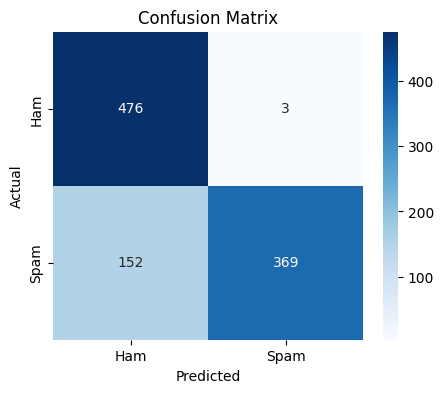

In [89]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Summary

In the course of the work, an email classifier based on the Naive Bayes algorithm was implemented.
Before training the model, text cleaning was performed.

The model was trained on a balanced sample of Spam and Ham messages and tested on a separate test sample. The results of the testing showed Accuracy = 84.5%. For the Spam class, the Precision value is 0.99, which indicates a very small number of false positives. Recall for Spam is 0.71, so some spam messages remain undetected. The error matrix showed only 3 False Positive errors, but 152 False Negative errors.

The results obtained show that the implemented classifier recognizes normal messages quite reliably and almost does not attribute them to spam.